In [1]:
!pip install lime shap
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cf4058822c77e4fa0a71d9d6b035b34cff6b99d618178a665f076682423f7cf8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import lime
import lime.lime_tabular
from statsmodels.stats.outliers_influence import variance_inflation_factor
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

In [3]:
# 1. DATA Loading
df = pd.read_csv('/content/cardiovascular_diseases_processed.csv')
df

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
68778,53,2,168,76,120,80,1,1,1,0,1,0
68779,62,1,158,126,140,90,2,2,0,0,1,1
68780,52,2,183,105,180,90,3,1,0,1,0,1
68781,61,1,163,72,135,80,1,2,0,0,0,1


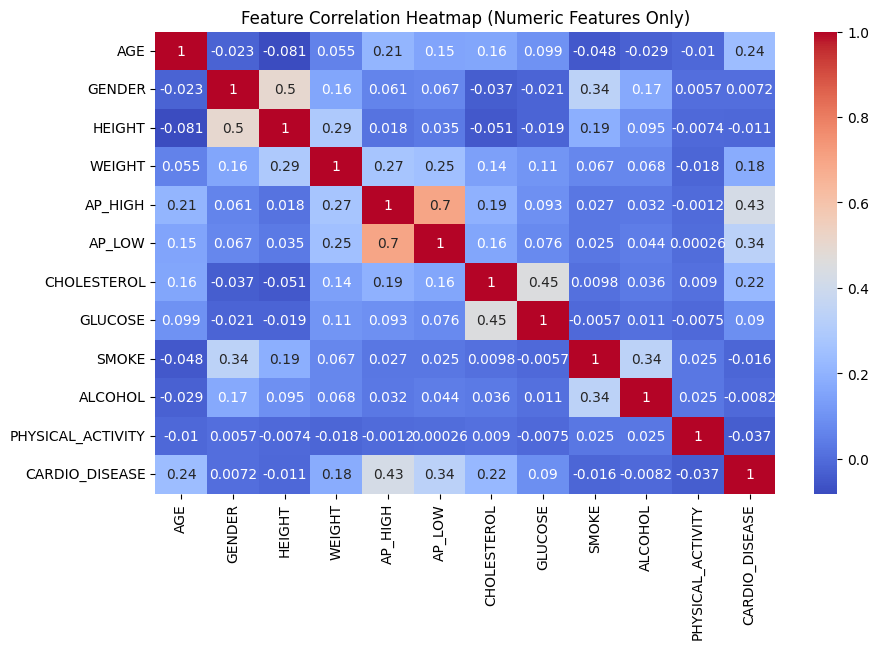

In [4]:
# EDA: Correlation Heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Numeric Features Only)")
plt.show()

In [5]:
# Identify the label column based on the dataset's specific naming convention
possible_targets = ['CARDIO_DISEASE', 'HeartDisease', 'output', 'target']
target_col = next((col for col in possible_targets if col in df.columns), None)

if target_col is None:
    raise ValueError(f"Could not find a target column. Available columns: {df.columns.tolist()}")

In [6]:
# 2. ENCODING: Convert text to numbers
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

In [7]:
X_with_const = X.assign(const=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(len(X_with_const.columns))
]
print(vif_data.sort_values(by="VIF", ascending=False))

              feature         VIF
11              const  635.166768
4             AP_HIGH    2.048850
5              AP_LOW    1.968635
1              GENDER    1.464058
2              HEIGHT    1.446520
6         CHOLESTEROL    1.319994
7             GLUCOSE    1.260631
8               SMOKE    1.248014
3              WEIGHT    1.211624
9             ALCOHOL    1.139708
0                 AGE    1.072201
10  PHYSICAL_ACTIVITY    1.001782


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. SCALING:
# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Target column identified as:", target_col)
print("Number of features after encoding:", X_train_scaled.shape[1])

Preprocessing complete. Target column identified as: CARDIO_DISEASE
Number of features after encoding: 11


In [9]:
# 2. MODEL BUILDING & TRAINING
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# 3. EVALUATION
y_pred = lr_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7318
AUC Score: 0.7960
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6924
           1       0.76      0.67      0.71      6833

    accuracy                           0.73     13757
   macro avg       0.74      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



Generating SHAP Summary Plot...


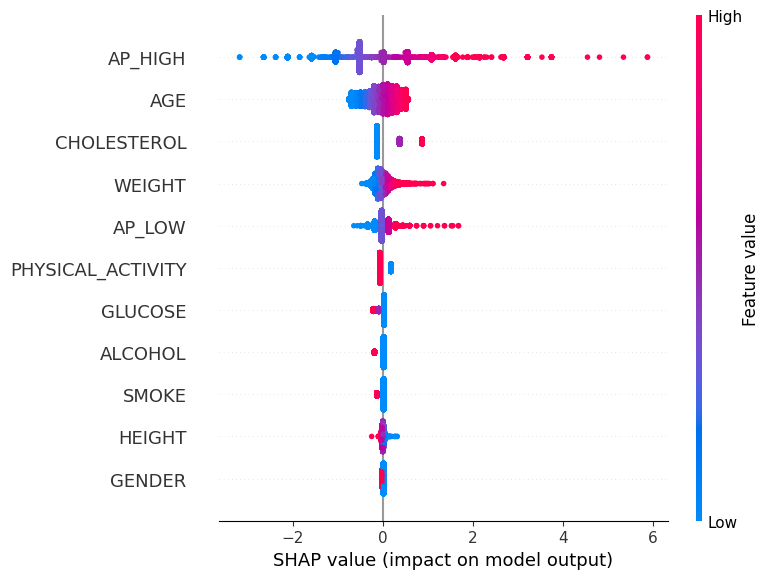

In [10]:
# 4. EXPLAINABLE AI (XAI) TECHNIQUES
# Technique 1: SHAP
explainer = shap.Explainer(lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

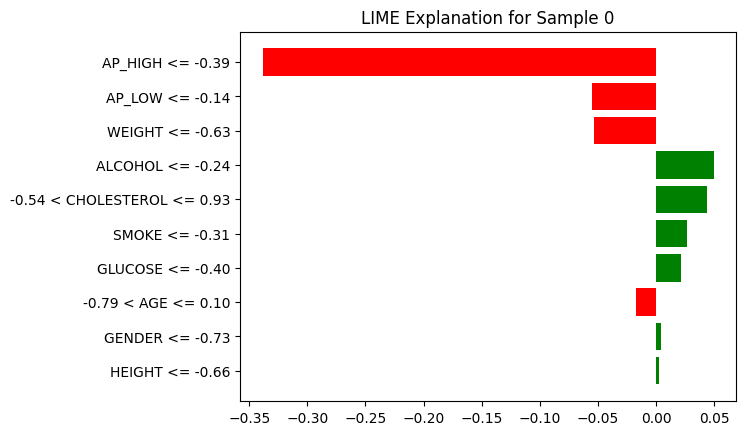

In [11]:
# Technique 2: LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
exp = lime_explainer.explain_instance(X_test_scaled[0], lr_model.predict_proba)
exp.as_pyplot_figure()
plt.title("LIME Explanation for Sample 0")
plt.show()

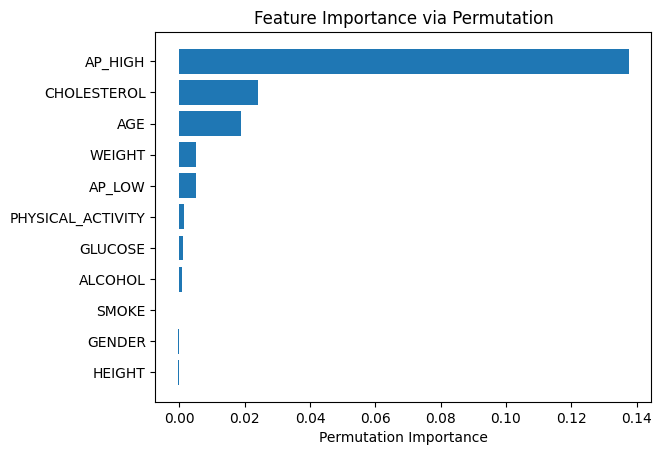

In [12]:
# Technique 3: Permutation Importance
result = permutation_importance(lr_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Feature Importance via Permutation")
plt.show()

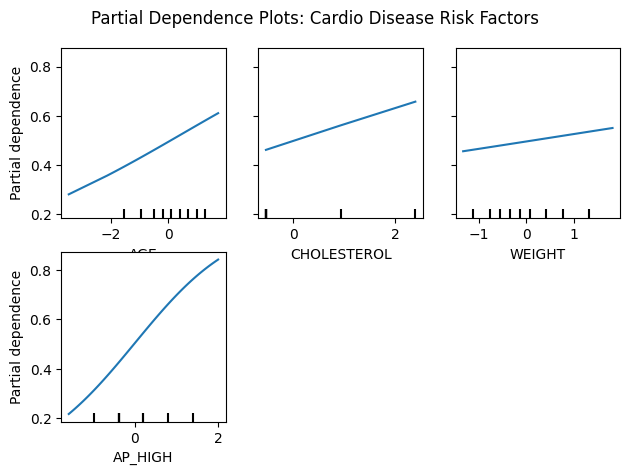

In [13]:
# Technique 4: Partial Dependence Plots (PDP)
features_to_plot = [col for col in ['AGE', 'CHOLESTEROL', 'WEIGHT', 'AP_HIGH'] if col in X.columns]

if not features_to_plot:
    features_to_plot = [0, 1, 2]

PartialDependenceDisplay.from_estimator(
    lr_model,
    X_train_scaled,
    features_to_plot,
    feature_names=X.columns.tolist(),
    target=1
)
plt.suptitle("Partial Dependence Plots: Cardio Disease Risk Factors")
plt.tight_layout()
plt.show()

Model 2 : Stacking Ensemble

In [14]:
# 1. Define Base Learners (Layer 1) - Based on the "Good but Different" principle [cite: 164, 451]
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42)),
    ('catboost', CatBoostClassifier(silent=True, random_state=42))
]

In [15]:
# 2. Define Meta-Learner (Layer 2) - Paper uses Logistic Regression to avoid overfitting [cite: 25, 86, 174]
meta_learner = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)

In [16]:
# 3. Build Stacking Model
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5 # as used in the paper
)

# 4. Train
stack_model.fit(X_train_scaled, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('et', ExtraTreesClassifier(random_state=42)),
                               ('mlp',
                                MLPClassifier(max_iter=1000, random_state=42)),
                               ('catboost',
                                CatBoostClassifier(random_state=42, silent=True))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [17]:
# 5. Evaluate
y_pred_stack = stack_model.predict(X_test_scaled)
print("Stacking Model Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, stack_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

Stacking Model Results
Accuracy: 0.7375
AUC Score: 0.8062


Generating SHAP Summary Plot


  0%|          | 0/10 [00:00<?, ?it/s]

SHAP values shape: (10, 11)
Data shape: (10, 11)


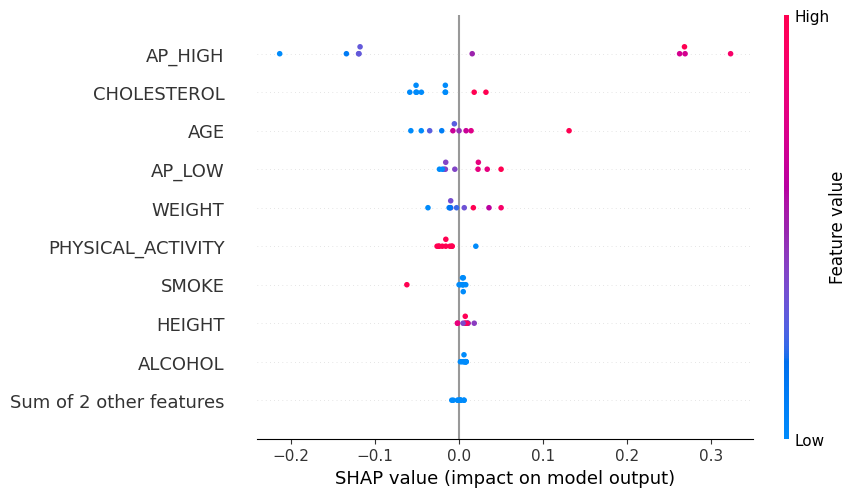

In [18]:
# Technique 1: SHAP (Corrected for Stacking Model)
print("Generating SHAP Summary Plot")
background = shap.sample(X_train_scaled, 50)
explainer_stack = shap.KernelExplainer(stack_model.predict_proba, background)
shap_values_list = explainer_stack.shap_values(X_test_scaled[:10])

if isinstance(shap_values_list, list):
    shap_values_array = np.array(shap_values_list[1])
else:
    shap_values_array = shap_values_list[:, :, 1]

if shap_values_array.ndim == 3:
    shap_values_array = shap_values_array[:, :, 1]

data_array = np.array(X_test_scaled[:10])

explanation = shap.Explanation(
    values=shap_values_array,
    data=data_array,
    feature_names=X.columns.tolist()
)
print(f"SHAP values shape: {shap_values_array.shape}")
print(f"Data shape: {data_array.shape}")
assert shap_values_array.shape == data_array.shape, \
    f"Shape mismatch: {shap_values_array.shape} vs {data_array.shape}"

shap.plots.beeswarm(explanation)

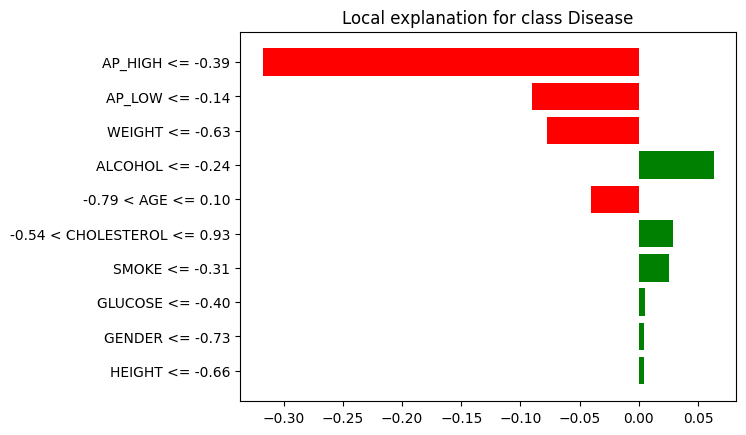

In [19]:
# Technique 2: LIME
lime_stack = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
lime_stack.explain_instance(X_test_scaled[0], stack_model.predict_proba).as_pyplot_figure()
plt.show()

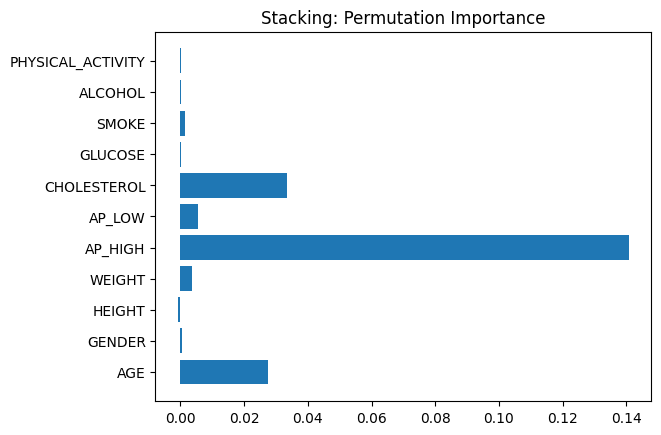

In [20]:
# Technique 3: Permutation Importance
result_stack = permutation_importance(stack_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
plt.barh(X.columns, result_stack.importances_mean)
plt.title("Stacking: Permutation Importance")
plt.show()

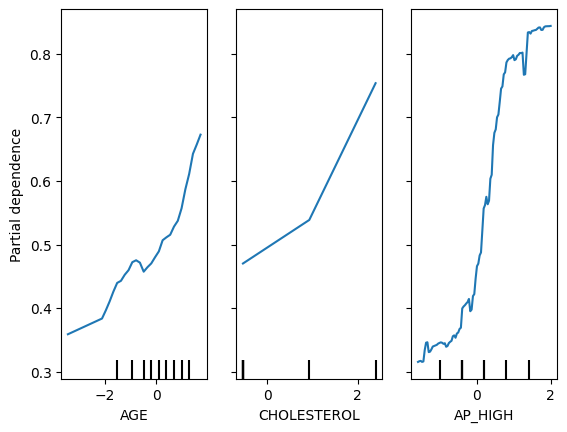

In [21]:
# Technique 4: Partial Dependence Plots (PDP)
features_to_plot = [col for col in ['AGE', 'CHOLESTEROL', 'AP_HIGH'] if col in X.columns]
PartialDependenceDisplay.from_estimator(stack_model, X_train_scaled, features_to_plot, feature_names=X.columns.tolist(), target=1)
plt.show()

Model 3 : SVM

In [ ]:
# 1. Initialize SVM
svm_model = SVC(
    kernel='rbf',
    probability=True,
    C=1.0,
    random_state=42
)

# 2. Train
svm_model.fit(X_train_scaled, y_train)

In [ ]:
# 3. Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)
print("--- SVM Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

In [ ]:
#  XAI TECHNIQUES
# Technique 1: SHAP
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, background)
shap_values_svm = explainer_svm.shap_values(X_test_scaled[:10])
shap.summary_plot(shap_values_svm[1], X_test_scaled[:10], feature_names=X.columns)

In [ ]:
# Technique 2: LIME
lime_svm = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
lime_svm.explain_instance(X_test_scaled[0], svm_model.predict_proba).as_pyplot_figure()
plt.show()

In [ ]:
# Technique 3: Permutation Importance
result_svm = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
plt.barh(X.columns, result_svm.importances_mean)
plt.title("SVM: Permutation Importance")
plt.show()

In [ ]:
# Technique 4: Partial Dependence Plots (PDP)
PartialDependenceDisplay.from_estimator(svm_model, X_train_scaled, features_to_plot, feature_names=X.columns.tolist(), target=1)
plt.show()